In [26]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('../../'))

# Imports essentiels
import geopandas as gpd
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print("📦 Libraries importées avec succès !")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
📦 Libraries importées avec succès !


In [ ]:
# Configuration
output_dir = "../../Data/input/networkGG"

# Configuration de la zone d'étude
area_mode = 'geocode'  # 'shapefile' ou 'geocode'
places = ['Genève, Switzerland', 'Collonge-Bellerive, Switzerland', 'Cologny, Switzerland'] # if geocode e.g. Versoix, Switzerland', 'Divonne-les-Bains, France', 'Nyon, Switzerland

# Configuration des réseaux à télécharger
download_walking = True    # Télécharger le réseau marchable
download_cycling = True    # Télécharger le réseau cyclable
download_platforms = True  # Télécharger les plateformes de transport

# Configuration de l'export
export_formats = ['parquet', 'geojson']  # formats d'export souhaités
export_nodes = True        # Exporter les nœuds
export_edges = True        # Exporter les arêtes
export_platforms_separate = True  # Exporter les plateformes dans des fichiers séparés

print("📋 Configuration:")
print(f"  • Réseaux: Marche={download_walking}, Vélo={download_cycling}, Plateformes={download_platforms}")
print(f"  • Export: Nœuds={export_nodes}, Arêtes={export_edges}, Plateformes séparées={export_platforms_separate}")
print(f"  • Formats: {export_formats}")

## 1. Chargement de la zone d'étude

🗺️ Chargement de la zone d'étude...
🌐 Géocodage des lieux: ['Genève, Switzerland', 'Collonge-Bellerive, Switzerland', 'Cologny, Switzerland']
  ✅ Genève, Switzerland
  ✅ Collonge-Bellerive, Switzerland
  ✅ Cologny, Switzerland
✅ Zone d'étude créée: 1 feature(s)
📐 Superficie: 36.42 km²


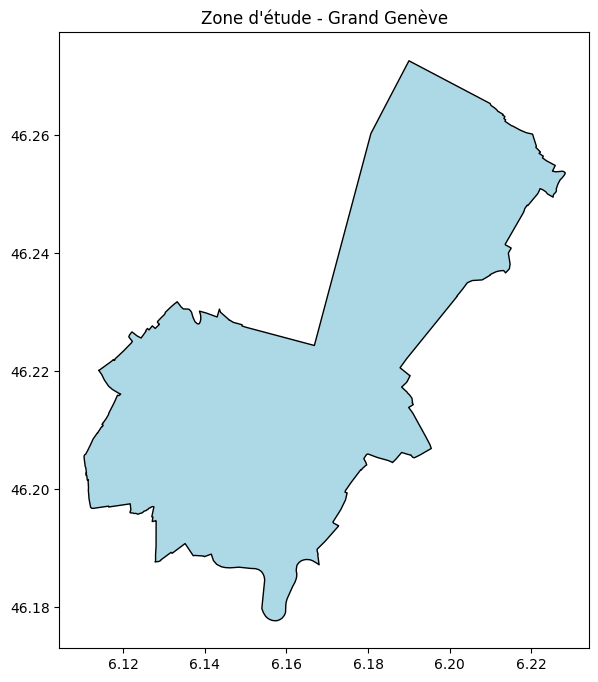

CPU times: user 77 ms, sys: 18.3 ms, total: 95.3 ms
Wall time: 2.63 s


In [28]:
%%time
print("🗺️ Chargement de la zone d'étude...")

if area_mode == 'shapefile':"../../Data/input/network_agreg/AGGLO_PERIMETRE_AVEC_LAC-SHP/AGGLO_PERIMETRE_AVEC_LAC.shp"
    shp_path = 
    print(f"📂 Lecture du shapefile: {shp_path}")
    
    if os.path.exists(shp_path):
        study_area = gpd.read_file(shp_path)
        if len(study_area) > 1:
            study_area = study_area.dissolve()
        study_area = study_area.to_crs('EPSG:4326')
        print(f"✅ Zone d'étude chargée: {len(study_area)} feature(s)")
    else:
        raise FileNotFoundError(f"Shapefile introuvable: {shp_path}")

elif area_mode == 'geocode':
    
    print(f"🌐 Géocodage des lieux: {places}")
    
    gdfs = []
    for place in places:
        try:
            gdf = ox.geocode_to_gdf(place)
            if gdf is not None and len(gdf) > 0:
                gdfs.append(gdf.to_crs('EPSG:4326'))
                print(f"  ✅ {place}")
        except Exception as e:
            print(f"  ❌ Erreur pour {place}: {e}")
    
    if gdfs:
        union_geom = gdfs[0].geometry.union_all()
        for gdf in gdfs[1:]:
            union_geom = union_geom.union(gdf.geometry.union_all())
        study_area = gpd.GeoDataFrame({'name': ['study_area']}, geometry=[union_geom], crs='EPSG:4326')
        print(f"✅ Zone d'étude créée: {len(study_area)} feature(s)")
    else:
        raise ValueError("Aucune zone géocodée avec succès")

# Calcul de la superficie
area_km2 = study_area.to_crs('EPSG:2056').geometry.area.iloc[0] / 1e6
print(f"📐 Superficie: {area_km2:.2f} km²")

# Visualisation
study_area.plot(figsize=(8, 8), color='lightblue', edgecolor='black')
plt.title("Zone d'étude - Grand Genève")
plt.show()

## 2. Définition des attributs à récupérer

In [29]:
# Attributs essentiels pour la marche
walking_attributes = {
    # Infrastructures piétonnes principales
    'highway': ['footway', 'pedestrian', 'steps', 'path', 'living_street', 
               'residential', 'tertiary', 'unclassified', 'service'],
    
    # Accès et permissions
    'foot': True,
    'sidewalk': True,
    
    # Traversées et croisements
    'crossing': True,
    'crossing:signals': True,
    'tactile_paving': True,
    
    # Qualité du revêtement
    'surface': True,
    'smoothness': True,
    
    # Attributs géométriques
    'width': True,
    'incline': True,
    'step_count': True
}

# Plateformes de transport public
platform_attributes = {
    'public_transport': ['platform', 'stop_position'],
    'railway': ['platform', 'tram_stop'],
    'amenity': ['bus_station'],
    'highway': ['bus_stop', 'platform']
}

# Attributs essentiels pour le vélo
cycling_attributes = {
    # Infrastructures cyclables
    'highway': ['cycleway', 'primary', 'secondary', 'tertiary', 'residential', 
               'unclassified', 'service', 'living_street', 'path'],
    
    # Aménagements cyclables
    'cycleway': True,
    'cycleway:left': True,
    'cycleway:right': True,
    'cycleway:both': True,
    
    # Permissions et restrictions
    'bicycle': True,
    'access': True,
    'oneway': True,
    'oneway:bicycle': True,
    
    # Qualité et sécurité
    'surface': True,
    'smoothness': True,
    'lit': True,
    'segregated': True,
    
    # Géométrie et capacité
    'width': True,
    'lanes': True,
    'incline': True,
    'maxspeed': True
}

print("📝 Attributs définis pour :")
print(f"  • Marche: {len(walking_attributes)} catégories")
print(f"  • Plateformes: {len(platform_attributes)} catégories")
print(f"  • Vélo: {len(cycling_attributes)} catégories")

📝 Attributs définis pour :
  • Marche: 11 catégories
  • Plateformes: 4 catégories
  • Vélo: 17 catégories


## 3. Téléchargement des réseaux

In [30]:
%%time
print("🔄 Téléchargement des réseaux...")

poly = study_area.geometry.iloc[0]

# Variables pour stocker les réseaux
walking_network = None
cycling_network = None
platforms_gdf = None

# 1. Réseau marchable (walk network)
if download_walking:
    print("🚶 Téléchargement du réseau marchable...")
    walking_network = ox.graph_from_polygon(
        polygon=poly,
        network_type='walk',
        simplify=True,
        retain_all=True
    )
    print(f"  ✅ Réseau marchable: {len(walking_network.nodes)} nœuds, {len(walking_network.edges)} arêtes")

# 2. Réseau cyclable (bike network)
if download_cycling:
    print("🚲 Téléchargement du réseau cyclable...")
    cycling_network = ox.graph_from_polygon(
        polygon=poly,
        network_type='bike',
        simplify=True,
        retain_all=True
    )
    print(f"  ✅ Réseau cyclable: {len(cycling_network.nodes)} nœuds, {len(cycling_network.edges)} arêtes")

# 3. Plateformes de transport
if download_platforms:
    print("🚌 Récupération des plateformes de transport...")
    try:
        platforms = ox.features_from_polygon(poly, tags=platform_attributes)
        if platforms is not None and len(platforms) > 0:
            platforms_gdf = gpd.GeoDataFrame(platforms, geometry='geometry', crs='EPSG:4326')
        else:
            platforms_gdf = gpd.GeoDataFrame(columns=['geometry'], crs='EPSG:4326')
    except Exception:
        # Fallback avec bbox
        try:
            minx, miny, maxx, maxy = poly.bounds
            platforms = ox.features_from_bbox(maxy, miny, maxx, minx, tags=platform_attributes)
            if platforms is not None:
                platforms_gdf = gpd.clip(platforms, poly)
            else:
                platforms_gdf = gpd.GeoDataFrame(columns=['geometry'], crs='EPSG:4326')
        except Exception:
            platforms_gdf = gpd.GeoDataFrame(columns=['geometry'], crs='EPSG:4326')
    
    print(f"  ✅ Plateformes: {len(platforms_gdf)} éléments")

print(f"\n✅ Téléchargement terminé!")
if download_walking and walking_network:
    print(f"  • Marche: {len(walking_network.nodes)} nœuds, {len(walking_network.edges)} arêtes")
if download_cycling and cycling_network:
    print(f"  • Vélo: {len(cycling_network.nodes)} nœuds, {len(cycling_network.edges)} arêtes")
if download_platforms and platforms_gdf is not None:
    print(f"  • Plateformes: {len(platforms_gdf)} éléments")

🔄 Téléchargement des réseaux...
🚶 Téléchargement du réseau marchable...
🚲 Téléchargement du réseau cyclable...
🚌 Récupération des plateformes de transport...
✅ Réseaux téléchargés:
  • Marche: 19303 nœuds, 54076 arêtes
  • Vélo: 6559 nœuds, 13709 arêtes
  • Plateformes: 1076 éléments
CPU times: user 6.92 s, sys: 151 ms, total: 7.07 s
Wall time: 2min 46s


In [31]:
# Conversion en GeoDataFrames pour analyse
print("🔄 Conversion en GeoDataFrames...")

# Variables pour stocker les GeoDataFrames
walking_nodes_gdf = None
walking_edges_gdf = None
cycling_nodes_gdf = None
cycling_edges_gdf = None
platforms_final = None

# Réseaux marchables
if download_walking and walking_network:
    print("  🚶 Conversion réseau marchable...")
    walking_nodes_gdf = ox.graph_to_gdfs(walking_network, edges=False)
    walking_edges_gdf = ox.graph_to_gdfs(walking_network, nodes=False)
    print(f"    • {len(walking_nodes_gdf)} nœuds, {len(walking_edges_gdf)} arêtes")

# Réseaux cyclables
if download_cycling and cycling_network:
    print("  🚲 Conversion réseau cyclable...")
    cycling_nodes_gdf = ox.graph_to_gdfs(cycling_network, edges=False)
    cycling_edges_gdf = ox.graph_to_gdfs(cycling_network, nodes=False)
    print(f"    • {len(cycling_nodes_gdf)} nœuds, {len(cycling_edges_gdf)} arêtes")

# Traitement des plateformes : séparer points et polygones
if download_platforms and platforms_gdf is not None and len(platforms_gdf) > 0:
    print("  🚌 Traitement des plateformes...")
    platform_polygons = platforms_gdf[platforms_gdf.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
    platform_points = platforms_gdf[platforms_gdf.geometry.type == 'Point'].copy()
    
    # Tamponner les points pour créer de petites surfaces (3m de rayon)
    if len(platform_points) > 0:
        pts_utm = platform_points.to_crs('EPSG:3857')
        pts_utm['geometry'] = pts_utm.geometry.buffer(3)  # 3 mètres
        platform_points_buffered = pts_utm.to_crs('EPSG:4326')
        
        # Combiner polygones et points tamponnés
        platforms_final = pd.concat([platform_polygons, platform_points_buffered], ignore_index=True)
    else:
        platforms_final = platform_polygons
    print(f"    • {len(platforms_final)} plateformes finales")
elif download_platforms:
    platforms_final = gpd.GeoDataFrame(columns=['geometry'], crs='EPSG:4326')

print(f"\n📊 Résultats conversion:")
if walking_nodes_gdf is not None:
    print(f"  • Nœuds marchables: {len(walking_nodes_gdf)}")
if walking_edges_gdf is not None:
    print(f"  • Arêtes marchables: {len(walking_edges_gdf)}")
if cycling_nodes_gdf is not None:
    print(f"  • Nœuds cyclables: {len(cycling_nodes_gdf)}")
if cycling_edges_gdf is not None:
    print(f"  • Arêtes cyclables: {len(cycling_edges_gdf)}")
if platforms_final is not None:
    print(f"  • Plateformes finales: {len(platforms_final)}")

🔄 Conversion en GeoDataFrames...
📊 Résultats:
  • Nœuds marchables: 19303
  • Arêtes marchables: 54076
  • Nœuds cyclables: 6559
  • Arêtes cyclables: 13709
  • Plateformes finales: 699


## 4. Analyse et classification des infrastructures

In [32]:
# Classification des infrastructures
print("🏷️ Classification des infrastructures...")

# Ajout de catégories fonctionnelles pour la marche
def classify_walking_infrastructure(row):
    highway_type = row.get('highway', '')
    sidewalk = row.get('sidewalk', '')
    foot = row.get('foot', '')
    
    if highway_type in ['footway', 'pedestrian', 'steps']:
        return 'infrastructure_dediee'
    elif highway_type in ['living_street']:
        return 'zone_partagee'
    elif sidewalk in ['both', 'left', 'right', 'yes']:
        return 'route_avec_trottoir'
    elif highway_type in ['residential', 'tertiary', 'unclassified', 'service'] and foot != 'no':
        return 'route_sans_trottoir_identifie'
    else:
        return 'autre'

# Classification des infrastructures marchables
if download_walking and walking_edges_gdf is not None:
    print("  🚶 Classification des infrastructures marchables...")
    walking_edges_gdf['infra_type'] = walking_edges_gdf.apply(classify_walking_infrastructure, axis=1)
    print("\n📊 Répartition des infrastructures marchables:")
    print(walking_edges_gdf['infra_type'].value_counts())

# Classification des infrastructures cyclables
def classify_cycling_infrastructure(row):
    highway_type = row.get('highway', '')
    cycleway = row.get('cycleway', '')
    cycleway_left = row.get('cycleway:left', '')
    cycleway_right = row.get('cycleway:right', '')
    
    if highway_type == 'cycleway':
        return 'piste_cyclable'
    elif cycleway in ['lane', 'track'] or cycleway_left in ['lane', 'track'] or cycleway_right in ['lane', 'track']:
        if 'track' in [cycleway, cycleway_left, cycleway_right]:
            return 'piste_cyclable'
        else:
            return 'bande_cyclable'
    elif highway_type in ['residential', 'living_street', 'service']:
        return 'route_apaisee'
    elif highway_type in ['primary', 'secondary', 'tertiary']:
        return 'route_principale'
    else:
        return 'autre'

if download_cycling and cycling_edges_gdf is not None:
    print("  🚲 Classification des infrastructures cyclables...")
    cycling_edges_gdf['infra_type'] = cycling_edges_gdf.apply(classify_cycling_infrastructure, axis=1)
    print("\n📊 Répartition des infrastructures cyclables:")
    print(cycling_edges_gdf['infra_type'].value_counts())

print("\n✅ Classification terminée")

🚶 Classification des infrastructures marchables...
🚲 Classification des infrastructures cyclables...

📊 Répartition des infrastructures marchables:
infra_type
infrastructure_dediee            33408
route_sans_trottoir_identifie    15118
autre                             4902
zone_partagee                      648
Name: count, dtype: int64

📊 Répartition des infrastructures cyclables:
infra_type
route_apaisee       8525
route_principale    2858
autre               1659
piste_cyclable       667
Name: count, dtype: int64


## 5. Export des données

In [33]:
# Préparation des données pour l'export
print("🔄 Préparation des données pour l'export...")

# Normalisation des colonnes pour la compatibilité Parquet
def normalize_for_export(gdf):
    """Convertit les colonnes list-like en format compatible pour tous les exports"""
    if gdf is None:
        return None
        
    gdf_export = gdf.copy()
    
    # Traitement spécial pour osmid
    if 'osmid' in gdf_export.columns:
        gdf_export['osmid'] = gdf_export['osmid'].apply(
            lambda x: x if isinstance(x, list) else ([x] if pd.notnull(x) else [])
        )
    
    # Conversion des autres colonnes list-like
    for col in gdf_export.columns:
        if col != 'osmid':
            try:
                has_list = gdf_export[col].apply(lambda x: isinstance(x, list)).any()
                if has_list:
                    gdf_export[col] = gdf_export[col].apply(
                        lambda x: x if isinstance(x, list) else ([x] if pd.notnull(x) else [])
                    )
            except Exception:
                continue
    
    return gdf_export

# Normalisation des données selon la configuration
walking_nodes_export = None
walking_edges_export = None
cycling_nodes_export = None
cycling_edges_export = None

if download_walking:
    if export_nodes and walking_nodes_gdf is not None:
        walking_nodes_export = normalize_for_export(walking_nodes_gdf)
        print(f"  ✅ Nœuds marchables normalisés: {len(walking_nodes_export)}")
    
    if export_edges and walking_edges_gdf is not None:
        walking_edges_export = normalize_for_export(walking_edges_gdf)
        print(f"  ✅ Arêtes marchables normalisées: {len(walking_edges_export)}")

if download_cycling:
    if export_nodes and cycling_nodes_gdf is not None:
        cycling_nodes_export = normalize_for_export(cycling_nodes_gdf)
        print(f"  ✅ Nœuds cyclables normalisés: {len(cycling_nodes_export)}")
    
    if export_edges and cycling_edges_gdf is not None:
        cycling_edges_export = normalize_for_export(cycling_edges_gdf)
        print(f"  ✅ Arêtes cyclables normalisées: {len(cycling_edges_export)}")

print("✅ Données normalisées pour l'export")

🔄 Préparation des données pour l'export...
✅ Données normalisées pour l'export


In [34]:
# Export dans les formats choisis
import os

os.makedirs(output_dir, exist_ok=True)

def export_gdf(gdf, name, formats):
    """Exporte un GeoDataFrame dans les formats spécifiés"""
    if gdf is None or len(gdf) == 0:
        print(f"⚠️ {name}: aucune donnée à exporter")
        return []
        
    exported_files = []
    
    for fmt in formats:
        try:
            if fmt == 'parquet':
                file_path = os.path.join(output_dir, f"{name}.parquet")
                gdf.to_parquet(file_path)
                
            elif fmt == 'geojson':
                # Pour GeoJSON, convertir les listes en chaînes
                gdf_json = gdf.copy()
                for col in gdf_json.columns:
                    if col != 'geometry':
                        try:
                            if gdf_json[col].apply(lambda x: isinstance(x, list)).any():
                                gdf_json[col] = gdf_json[col].apply(
                                    lambda x: ', '.join(map(str, x)) if isinstance(x, list) else x
                                )
                        except Exception:
                            continue
                
                file_path = os.path.join(output_dir, f"{name}.geojson")
                gdf_json.to_file(file_path, driver='GeoJSON')
                
            elif fmt == 'shapefile':
                # Pour Shapefile, même traitement que GeoJSON + limitation des noms de colonnes
                gdf_shp = gdf.copy()
                for col in gdf_shp.columns:
                    if col != 'geometry':
                        try:
                            if gdf_shp[col].apply(lambda x: isinstance(x, list)).any():
                                gdf_shp[col] = gdf_shp[col].apply(
                                    lambda x: ', '.join(map(str, x)) if isinstance(x, list) else x
                                )
                        except Exception:
                            continue
                
                # Limitation des noms de colonnes à 10 caractères
                gdf_shp.columns = [col[:10] if col != 'geometry' else col for col in gdf_shp.columns]
                
                shp_dir = os.path.join(output_dir, f"shp_{name}")
                os.makedirs(shp_dir, exist_ok=True)
                file_path = os.path.join(shp_dir, f"{name}.shp")
                gdf_shp.to_file(file_path)
            
            exported_files.append(file_path)
            print(f"    ✅ {fmt.upper()}: {file_path}")
            
        except Exception as e:
            print(f"    ❌ Erreur export {fmt.upper()} pour {name}: {e}")
    
    return exported_files

print(f"💾 Export des données (formats: {export_formats})...\n")

# Construction de la liste des exports selon la configuration
datasets_to_export = []

# Ajout des données marchables
if download_walking:
    if export_nodes and walking_nodes_export is not None:
        datasets_to_export.append((walking_nodes_export, "walking_nodes"))
    if export_edges and walking_edges_export is not None:
        datasets_to_export.append((walking_edges_export, "walking_edges"))

# Ajout des données cyclables
if download_cycling:
    if export_nodes and cycling_nodes_export is not None:
        datasets_to_export.append((cycling_nodes_export, "cycling_nodes"))
    if export_edges and cycling_edges_export is not None:
        datasets_to_export.append((cycling_edges_export, "cycling_edges"))

# Ajout des plateformes si export séparé activé
if download_platforms and export_platforms_separate and platforms_final is not None:
    datasets_to_export.append((platforms_final, "transport_platforms"))

# Export des datasets
for gdf, name in datasets_to_export:
    print(f"📂 Export {name} ({len(gdf)} éléments):")
    export_gdf(gdf, name, export_formats)
    print()

# Message de fin selon la configuration
print("🎉 Export terminé!")
print(f"📁 Fichiers disponibles dans: {output_dir}")
if not datasets_to_export:
    print("⚠️  Aucun dataset configuré pour l'export - vérifiez vos paramètres de configuration")

💾 Export des données (formats: ['parquet', 'geojson'])...


📂 Export walking_nodes (19303 éléments):
✅ PARQUET: ../../Data/input/networkGG/walking_nodes.parquet
✅ GEOJSON: ../../Data/input/networkGG/walking_nodes.geojson

📂 Export walking_edges (54076 éléments):
✅ PARQUET: ../../Data/input/networkGG/walking_edges.parquet
✅ GEOJSON: ../../Data/input/networkGG/walking_edges.geojson

📂 Export cycling_nodes (6559 éléments):
✅ PARQUET: ../../Data/input/networkGG/cycling_nodes.parquet
✅ GEOJSON: ../../Data/input/networkGG/cycling_nodes.geojson

📂 Export cycling_edges (13709 éléments):
✅ PARQUET: ../../Data/input/networkGG/cycling_edges.parquet
✅ GEOJSON: ../../Data/input/networkGG/cycling_edges.geojson

📂 Export transport_platforms (699 éléments):
✅ PARQUET: ../../Data/input/networkGG/transport_platforms.parquet
✅ GEOJSON: ../../Data/input/networkGG/transport_platforms.geojson

🎉 Export terminé ! Fichiers disponibles dans: ../../Data/input/networkGG


## 6. Résumé et documentation

In [35]:
# Création d'un résumé de l'extraction
from datetime import datetime
import json

# Construction du résumé selon les données disponibles
summary = {
    'extraction_date': datetime.now().isoformat(),
    'configuration': {
        'area_mode': area_mode,
        'download_walking': download_walking,
        'download_cycling': download_cycling,
        'download_platforms': download_platforms,
        'export_nodes': export_nodes,
        'export_edges': export_edges,
        'export_platforms_separate': export_platforms_separate,
        'export_formats': export_formats
    },
    'study_area': {
        'method': area_mode,
        'area_km2': float(area_km2),
        'features': len(study_area)
    },
    'networks': {},
    'export_summary': {
        'datasets_exported': len([name for gdf, name in datasets_to_export if gdf is not None]),
        'output_directory': output_dir
    }
}

# Ajout des statistiques par réseau selon ce qui a été téléchargé
if download_walking and walking_edges_gdf is not None:
    summary['networks']['walking'] = {
        'nodes': len(walking_nodes_gdf) if walking_nodes_gdf is not None else 0,
        'edges': len(walking_edges_gdf),
        'infrastructure_types': walking_edges_gdf['infra_type'].value_counts().to_dict() if 'infra_type' in walking_edges_gdf.columns else {}
    }

if download_cycling and cycling_edges_gdf is not None:
    summary['networks']['cycling'] = {
        'nodes': len(cycling_nodes_gdf) if cycling_nodes_gdf is not None else 0,
        'edges': len(cycling_edges_gdf),
        'infrastructure_types': cycling_edges_gdf['infra_type'].value_counts().to_dict() if 'infra_type' in cycling_edges_gdf.columns else {}
    }

if download_platforms and platforms_final is not None:
    summary['networks']['platforms'] = {
        'total': len(platforms_final),
        'types': platforms_final.get('public_transport', pd.Series()).value_counts().to_dict() if len(platforms_final) > 0 else {}
    }

# Sauvegarde du résumé
summary_path = os.path.join(output_dir, 'extraction_summary.json')
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

# Affichage du résumé
print("📋 RÉSUMÉ DE L'EXTRACTION")
print("=" * 50)
print(f"📅 Date: {summary['extraction_date'][:19]}")
print(f"📍 Zone d'étude: {summary['study_area']['area_km2']:.2f} km² ({summary['study_area']['method']})")

print(f"\n⚙️  CONFIGURATION:")
print(f"  • Téléchargement: Marche={download_walking}, Vélo={download_cycling}, Plateformes={download_platforms}")
print(f"  • Export: Nœuds={export_nodes}, Arêtes={export_edges}, Plateformes séparées={export_platforms_separate}")

if 'walking' in summary['networks']:
    print(f"\n🚶 RÉSEAU MARCHABLE:")
    print(f"  • {summary['networks']['walking']['nodes']} nœuds")
    print(f"  • {summary['networks']['walking']['edges']} arêtes")
    for infra_type, count in summary['networks']['walking']['infrastructure_types'].items():
        print(f"    - {infra_type}: {count}")

if 'cycling' in summary['networks']:
    print(f"\n🚲 RÉSEAU CYCLABLE:")
    print(f"  • {summary['networks']['cycling']['nodes']} nœuds")
    print(f"  • {summary['networks']['cycling']['edges']} arêtes")
    for infra_type, count in summary['networks']['cycling']['infrastructure_types'].items():
        print(f"    - {infra_type}: {count}")

if 'platforms' in summary['networks']:
    print(f"\n🚌 PLATEFORMES DE TRANSPORT:")
    print(f"  • {summary['networks']['platforms']['total']} éléments")

print(f"\n💾 EXPORT:")
print(f"  • Datasets exportés: {summary['export_summary']['datasets_exported']}")
print(f"  • Formats: {', '.join(export_formats)}")
print(f"  • Dossier: {output_dir}")
print(f"  • Résumé: {summary_path}")

print("\n✅ Extraction terminée avec succès !")

📋 RÉSUMÉ DE L'EXTRACTION
📅 Date: 2025-12-18T10:47:43
📍 Zone d'étude: 36.42 km² (geocode)

🚶 RÉSEAU MARCHABLE:
  • 19303 nœuds
  • 54076 arêtes
    - infrastructure_dediee: 33408
    - route_sans_trottoir_identifie: 15118
    - autre: 4902
    - zone_partagee: 648

🚲 RÉSEAU CYCLABLE:
  • 6559 nœuds
  • 13709 arêtes
    - route_apaisee: 8525
    - route_principale: 2858
    - autre: 1659
    - piste_cyclable: 667

🚌 PLATEFORMES DE TRANSPORT:
  • 699 éléments

💾 EXPORT:
  • Formats: parquet, geojson
  • Dossier: ../../Data/input/networkGG
  • Résumé: ../../Data/input/networkGG/extraction_summary.json

✅ Extraction terminée avec succès !
